# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 2
## Due date: <u> 23:59, Sunday the 10th May, 2026 </u>




## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation, you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 2 self grading due date: <u> 23:59, Monday the 18th May, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 11th May with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 18th May. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 18th May, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.





## Submission guideline:

* One submission per group by the due date on LMS.
* Answer the exercise questions in this Python notebook itself.
* Export your notebook file (.ipynb) as a PDF file, on which we give marks and comments. This means that each group should submit two versions of the exercise report (.ipynb file and PDF).
* Demonstrators will conduct a brief oral assessment for selected groups in subsequent workshop. Details will be announced on LMS.
* Regarding the use of LLM and other generative AI tools: refer to information in the introductory slides.





## Question 1 (Bayesian infrence, MLE and MAP) (Mark:  5 + 7 + 2 + 6 = 20 points)
In this question, we'll explore Bayesian infrence, MLE and MAP.

In [517]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"
from scipy.stats import bernoulli, beta

**A lucky find**

On the way to class, you discover an unusual coin on the ground.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/68/1_2_penny_Middlesex_DukeYork_1795_1ar85_%288737903267%29.jpg" alt="Coin" width="350"/>

As a dedicated student in SOML, you're interested in determining whether the coin is _biased_.
More specifically, you want to estimate the probability $\theta$ that the coin will land heads-up when you toss it. If $\theta \approx \frac{1}{2}$ then we say that the coin is _unbiased_ (or fair).

You can use the function below to simulate a coin toss: it returns `1` for heads and `0` for tails.

In [518]:
def toss_coin():
    if bernoulli.rvs(p = (int.from_bytes("coin".encode(), 'little') % 10000)/10000):
        return 1
    return 0

In [519]:
(int.from_bytes("coin".encode(), 'little') % 10000)/10000

0.3555

**Prior belief**

Before you even toss the coin, you notice that the heads side appears to have more mass.
Thus, your _prior belief_ is that $\theta$ is slightly biased away from $\frac{1}{2}$ towards 0—i.e. you expect tails are more likely.

To quantify this prior belief, we assume that the prior distribution for $\theta$ is $\mathrm{Beta}(a,b)$, for some choice of the hyperparameters $a, b > 0$.
(See [link](https://en.wikipedia.org/wiki/Beta_distribution) for info about the Beta distribution.)
The prior probability density function for $\theta$ is therefore given by:

$$ p(\theta) = \frac{1}{B(a,b)} \theta^{a-1} (1 - \theta)^{b-1} $$

where $B(a,b)$ is a special function called the _Beta function_.

Select appropriate values for $a$ and $b$ by looking at the plot of $p(\theta)$ below.

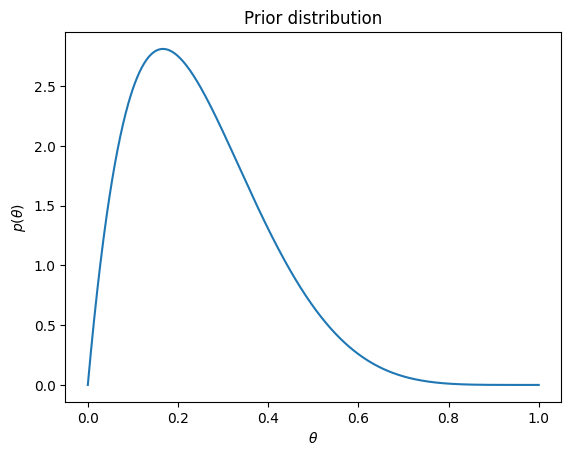

In [520]:
a = 2 # fill in
b = 6 # fill in
theta = np.linspace(0, 1, 1001)
plt.plot(theta, beta.pdf(theta, a, b))
plt.title('Prior distribution')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta)$')
plt.show()

**Posterior updates:** Now toss the coin once and denote the outcome by $x_1$.

In [521]:
x1 = toss_coin()
print(x1)

# Counters
n_H = 0  # number of heads
n = 0    # total tosses

# Storage for estimates
mle_estimates = []
map_estimates = []

n += 1
n_H += x1

# MLE: n_H / n
theta_mle = n_H / n
mle_estimates.append(theta_mle)

# MAP: (n_H + a - 1) / (n + a + b - 2)
theta_map = (n_H + a - 1) / (n + a + b - 2)
map_estimates.append(theta_map)

0


We can update our belief about $\theta$, based on this new evidence $x_1$.
To do this we apply Bayes' rule to compute the posterior for $\theta$:

$$ p(\theta | x_1) = \frac{p(x_1 | \theta) \, p(\theta)}{p(x_1)} \propto p(x_1 | \theta) \, p(\theta)$$

where $p(\theta)$ is the prior given above and

$$ p(x_1 | \theta) = \theta^{x_1} (1 - \theta)^{1 - x_1} $$

is the likelihood.

\[Note: We always assume the tosses are independent, otherwise the likelihood for $x_2$ would depend on $x_1$.\]
***


### Part A: Mathematical Derivation

Toss the coin a second time, denoting the outcome by $x_2$.

In [522]:
x2 = toss_coin()
print(x2)

n += 1
n_H += x2

# MLE: n_H / n
theta_mle = n_H / n
mle_estimates.append(theta_mle)

# MAP: (n_H + a - 1) / (n + a + b - 2)
theta_map = (n_H + a - 1) / (n + a + b - 2)
map_estimates.append(theta_map)

0


Again, we want to update our belief about $\theta$ based on the new information $x_2$.
We take the previous posterior $p(\theta|x_1)$ as the new prior and apply Bayes' rule:

$$ p(\theta | x_1, x_2) \propto p(x_2 | \theta) p(\theta | x_1)$$



***
Show that for $n$ coin tosses, the posterior is $\theta | x_1, \ldots, x_n \sim \operatorname{Beta}[n_H + a, n - n_H + b]$ where $n_H = \sum_{i = 1}^{n} x_i$ is the number of heads observed.

***

***

### Part A Answer

The Beta prior is:

$$
p(\theta) \propto \theta^{a-1}(1-\theta)^{b-1}.
$$

For independent coin tosses $x_1, \dots, x_n \in \{0,1\}$, the likelihood is:

$$
p(x_1, \dots, x_n \mid \theta)
= \prod_{i=1}^n \theta^{x_i}(1-\theta)^{1-x_i}.
$$

Since $ n_H = \sum_{i=1}^n x_i $ is the number of heads. Then:

$$
p(x_1, \dots, x_n \mid \theta)
= \theta^{n_H}(1-\theta)^{n-n_H}.
$$

Applying Bayes’ rule:

$$
p(\theta \mid x_1, \dots, x_n)
\propto p(x_1, \dots, x_n \mid \theta)\, p(\theta).
$$

Substitute the prior and likelihood:

$$
p(\theta \mid x_1, \dots, x_n)
\propto \theta^{n_H}(1-\theta)^{n-n_H} \cdot \theta^{a-1}(1-\theta)^{b-1}.
$$

Combine exponents:

$$
p(\theta \mid x_1, \dots, x_n)
\propto \theta^{n_H + a - 1}(1-\theta)^{n - n_H + b - 1}.
$$

This is the kernel of a Beta distribution. Therefore,

$$
\theta \mid x_1, \dots, x_n \sim \operatorname{Beta}(n_H + a,\; n - n_H + b).
$$

$$
\boxed{
\theta \mid x_1, \ldots, x_n \sim \operatorname{Beta}(n_H + a,\; n - n_H + b)
}
$$

***

### Part B:  Mathematical Derivation for MAP estimator and MLE estimator

The posterior $\theta|x_1, \ldots, x_n$ contains all the information we know about $\theta$ after observing $n$ coin tosses.
One way of obtaining a point estimate of $\theta$ from the posterior, is to take the value with the maximum a posteriori probability (MAP):
$$
\begin{align}
    \hat{\theta}_\mathrm{MAP} &= \arg \max_{\theta} p(\theta|x_1, \ldots, x_n) \tag{1}
\end{align}
$$

In general, the MAP estimator gives a different result to the maximum likelihood estimator (MLE) for $\theta$:
$$
\begin{align}
    \hat{\theta}_\mathrm{MLE} &=\arg \max_{\theta} p(x_1, \ldots, x_n|\theta) \tag{2}\\
\end{align}
$$

***
 How would you derive the above results for $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$? Setup the equations for solving $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$ and then solve them.


***

### Part B Answer

#### 1. Maximum Likelihood Estimator (MLE)

Likelihood:
$$
p(x_1, \dots, x_n \mid \theta)
= \theta^{n_H}(1-\theta)^{n-n_H}
$$

Log-likelihood:
$$
\ell(\theta)
= n_H \log \theta + (n-n_H)\log(1-\theta)
$$

Differentiate:
$$
\frac{d\ell}{d\theta}
= \frac{n_H}{\theta} - \frac{n-n_H}{1-\theta}
$$

Set to zero:
$$
\frac{n_H}{\theta} = \frac{n-n_H}{1-\theta}
$$

Solve:
$$
n_H(1-\theta) = (n-n_H)\theta
$$

$$
n_H = n\theta
$$

Final result:
$$
\hat{\theta}_{\mathrm{MLE}} = \frac{n_H}{n}
$$


#### 2. Maximum A Posteriori (MAP) Estimator

Posterior (up to proportionality):
$$
p(\theta \mid x_1, \dots, x_n)
\propto \theta^{n_H+a-1}(1-\theta)^{n-n_H+b-1}
$$

Log-posterior:
$$
\log p(\theta \mid x)
= (n_H+a-1)\log\theta + (n-n_H+b-1)\log(1-\theta)
$$

Differentiate:
$$
\frac{d}{d\theta}
=
\frac{n_H+a-1}{\theta}
-
\frac{n-n_H+b-1}{1-\theta}
$$

Set to zero:
$$
\frac{n_H+a-1}{\theta}
=
\frac{n-n_H+b-1}{1-\theta}
$$

Solve:
$$
(n_H+a-1)(1-\theta) = (n-n_H+b-1)\theta
$$

$$
(n_H+a-1) = (n+a+b-2)\theta
$$

Final result:
$$
\hat{\theta}_{\mathrm{MAP}} =
\frac{n_H + a - 1}{n + a + b - 2}
$$


#### 3. Final Results

$$
\hat{\theta}_{\mathrm{MLE}} = \frac{n_H}{n}
$$

$$
\hat{\theta}_{\mathrm{MAP}} =
\frac{n_H + a - 1}{n + a + b - 2}
$$

***

### Part C: Programming
Let's now toss the coin an additional 100 times (so that $n = 102$) using the given function ``toss_coin()``. After each toss, compute and record $\hat{\theta}_\mathrm{MLE}$ and $\hat{\theta}_\mathrm{MAP}$ (using the expresssion you solved from Part B). Plot both estimates them as two lines on the same graph. To compute $\hat{\theta}_\mathrm{MAP}$, we set the parameters of the beta prior distribution as $a=2$ and $b=6$.

### Part C Answer

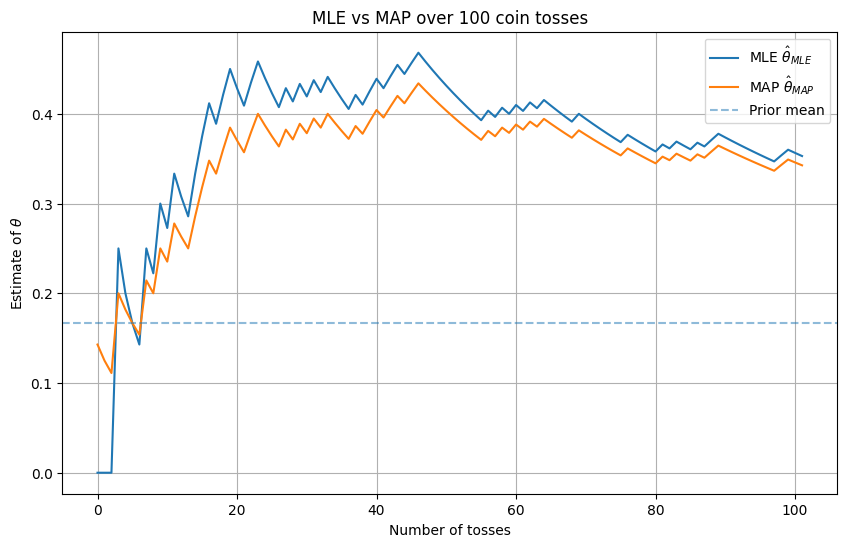

In [523]:
# Number of additional tosses
n_extra = 100

for _ in range(n_extra):
    x = toss_coin()
    n += 1
    n_H += x

    # MLE: n_H / n
    theta_mle = n_H / n
    mle_estimates.append(theta_mle)

    # MAP: (n_H + a - 1) / (n + a + b - 2)
    theta_map = (n_H + a - 1) / (n + a + b - 2)
    map_estimates.append(theta_map)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(mle_estimates, label=r'MLE $\hat{\theta}_{MLE}$')
plt.plot(map_estimates, label=r'MAP $\hat{\theta}_{MAP}$')
plt.axhline((a - 1) / (a + b - 2), linestyle='--', alpha=0.5, label='Prior mean')

plt.title('MLE vs MAP over 100 coin tosses')
plt.xlabel('Number of tosses')
plt.ylabel(r'Estimate of $\theta$')
plt.legend()
plt.grid()
plt.show()

### Part D: Online Learning for Coin Toss Prediction

In this task, you will consider an online learning problem for predicting the outcomes of a coin toss sequence.

Assume a sequence of coin toss outcomes
$$
x_1, x_2, \dots, x_n \sim P_\theta,
$$
where $x_i \in \{0,1\}$ and $\theta$ is the probability of observing a head $(x_i=1)$. Again, the parameter $\theta$ is unkown, and you only observe samples from this distribution.

You need **predict** the outcome at each time step $i$ given seen results of previous $(i-1)$ steps.
The reward at time $i$ is defined as:
$$
r_i =
\begin{cases}
+1, & \text{correct guess} \\
-1, & \text{wrong guess}
\end{cases}
$$



1) Develop a Maximum Likelihood Estimator based strategy that maximizes the total rewards:
$$
\max \sum_{i=1}^{n} r_i.
$$

**Data Generation**：Use the function ```toss_coin``` to generate one particular sample of 1000 coin tosses.

Note: Updating $\hat \theta$ by ML estimator, predict $\hat x_i$ as $1$ if $\hat \theta\ge 0.5$, otherwise predict it as zero. Set the first prediction as $1$ before seeing any toss results.




### Part D.1 Answer

Total reward: 212


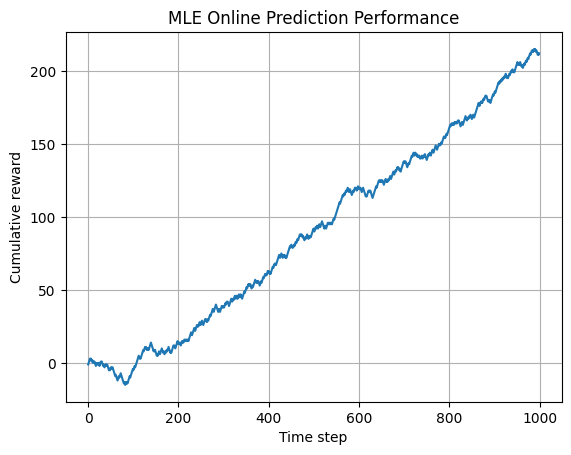

In [524]:
# Number of tosses
n = 1000

# Storage
predictions = []
rewards = []
theta_estimates = []

# Counters
n_H = 0  # number of heads observed

for i in range(1, n + 1):

    #prediction
    if i == 1:
        x_hat = 1  # set first prediction to 1
    else:
        theta_hat = n_H / (i - 1)
        x_hat = 1 if theta_hat >= 0.5 else 0

    predictions.append(x_hat)

    #observe true outcome
    x_i = toss_coin()

    #reward
    reward = 1 if x_hat == x_i else -1
    rewards.append(reward)

    #update counts
    n_H += x_i

    # store estimate
    theta_estimates.append(n_H / i)

# Total reward
total_reward = sum(rewards)
print("Total reward:", total_reward)

# Plot cumulative reward
cumulative_reward = np.cumsum(rewards)

plt.figure()
plt.plot(cumulative_reward)
plt.xlabel("Time step")
plt.ylabel("Cumulative reward")
plt.title("MLE Online Prediction Performance")
plt.grid()
plt.show()

To assess the performance of your strategy, you compare the rewards of your strategy to the case when the parameter $\theta$ is known, and the *optimal* prediction rule is used.

2) Specifically, now you know that the true parameter $\theta$ is $0.3555$. Let $r_i^*$ denote the reward at time $i$ using this optimal prediction rule.

We can define the *normalized regret* of the strategy as
$$
R_n: =  \frac{1}{n}(\sum_{i=1}^{n} r_i^* - \sum_{i=1}^n r_i)
$$

namely the difference between the optimal reward and the reward obtained by our strategy. It signifies the cost of not knowing the true parameter $\theta$.

What is the optimal prediction rule that maximizes the total *expected reward*? Calculate the normalized regret of your strategy given this particular sequence.


### Part D.2 Answer
Since the true parameter $\theta$ is $0.3555$, which is less than 0.5 so the optimal prediction should be 0 for all the toss. Code below is the calculation for normalized regret.

In [525]:
# Number of tosses
n = 1000

# Storage
rewards_mle = []
rewards_opt = []

# Counters
n_H = 0

# Generate ONE fixed sequence first
data = [toss_coin() for _ in range(n)]

for i in range(1, n + 1):
    x_i = data[i-1]

    # ----- MLE strategy -----
    if i == 1:
        x_hat = 1
    else:
        theta_hat = n_H / (i - 1)
        x_hat = 1 if theta_hat >= 0.5 else 0

    r_mle = 1 if x_hat == x_i else -1
    rewards_mle.append(r_mle)

    # ----- Optimal strategy (theta = 0.3555) -----
    x_star = 0  # always predict tail
    r_opt = 1 if x_star == x_i else -1
    rewards_opt.append(r_opt)

    # Update count
    n_H += x_i

# Compute normalized regret
R_n = (sum(rewards_opt) - sum(rewards_mle)) / n

print("Normalized regret:", R_n)

Normalized regret: 0.004


3) Generate sequences with various lengths (from $n=10$ to $n=1000$) using the same random seed as in the previous question. Plot $R_n$ against $n$. Comment on your observations.



**An Important Note**: This is an online prediction problem, not a batch prediction problem. Here you use this sequence with 100 tosses to design your strategy and verify your total rewards. However, the prediction must be made sequentially. To be specific, at time step $i$, you are only allowed to use the outcomes from the previous $i-1$ tosses, and you are not allowed to use the outcome of the current (and future) toss before making your prediction.

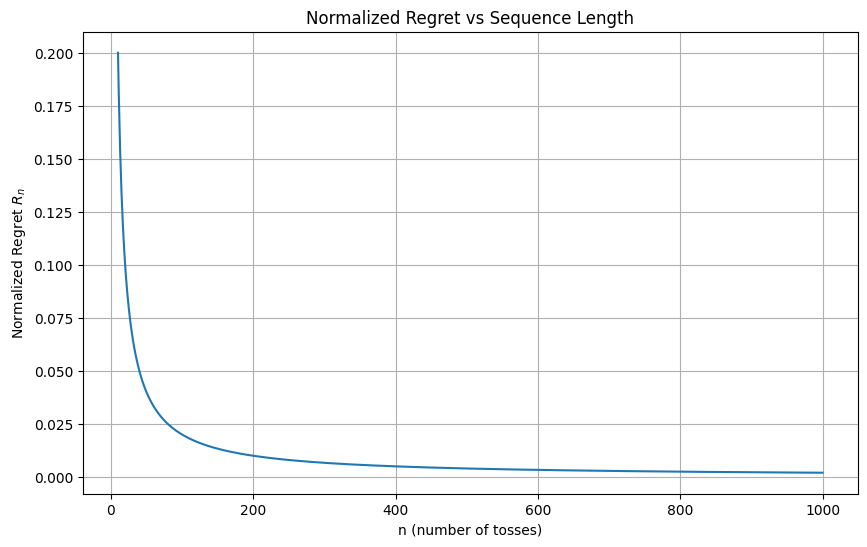

In [526]:
np.random.seed(202690088)# keep it
sequence = [toss_coin() for _ in range(1000)]

n_values = range(10, 1001)
regrets = []

theta_true = 0.3555  # given

for n in n_values:
    data = sequence[:n]

    # ----- MLE strategy -----
    n_H = 0
    rewards_mle = []
    rewards_opt = []

    for i in range(1, n + 1):
        # MLE prediction
        if i == 1:
            x_hat = 1
        else:
            theta_hat = n_H / (i - 1)
            x_hat = 1 if theta_hat >= 0.5 else 0

        x_i = data[i-1]
        r_mle = 1 if x_hat == x_i else -1
        rewards_mle.append(r_mle)

        # Optimal prediction (theta = 0.3555 → always 0)
        x_star = 0
        r_opt = 1 if x_star == x_i else -1
        rewards_opt.append(r_opt)

        # Update
        n_H += x_i

    # Normalized regret
    R_n = (sum(rewards_opt) - sum(rewards_mle)) / n
    regrets.append(R_n)

# Plot
plt.figure(figsize=(10,6))
plt.plot(n_values, regrets)
plt.xlabel('n (number of tosses)')
plt.ylabel(r'Normalized Regret $R_n$')
plt.title('Normalized Regret vs Sequence Length')
plt.grid()
plt.show()

Observation: At small $n$: $R_n$ is large, as $n$ increases: $R_n\to0$. Eventually $R_n$ becomes very close to $0$. This means *asymptotically*, our strategy (without the knowledge of the true parameter) will incur the same average loss as the optimal strategy.

(1 mark for correct plot, 1 mark for the correct observation)

## Question 2: K-means Clustering (Marks: 10 + 10 = 20 Points)


### Example: Clustering and Gaussian Mixtures
Unsupervised learning is all about data. We will use first the two circles dataset to practice a little bit and digest some of the fundemental concepts. Since two circles data inherently has two clusters (each circles as a cluster), we can use this as a [ground truth](https://en.wikipedia.org/wiki/Ground_truth). In most real problems, we don't have this luxury of having the ground truth at hand! This dataset can be directly available from the sklearn library, which is shown as follows.

**Note:** This two circles dataset is available from [*Scikit Learn*](https://scikit-learn.org/stable/user_guide.html). Hint: check [*cluster*](https://scikit-learn.org/stable/api/sklearn.cluster.html#), [*datasets*](https://scikit-learn.org/stable/api/sklearn.datasets.html), [*mixture*](https://scikit-learn.org/stable/api/sklearn.mixture.html#), [*utils*](https://scikit-learn.org/stable/api/sklearn.utils.html), [*decomposition*](https://scikit-learn.org/stable/api/sklearn.decomposition.html), and [*metrics*](https://scikit-learn.org/stable/api/sklearn.metrics.html).

Scikit Learn does not have its own global random state, uses the [numpy random state](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.seed.html#numpy.random.seed) instead. See the code below.

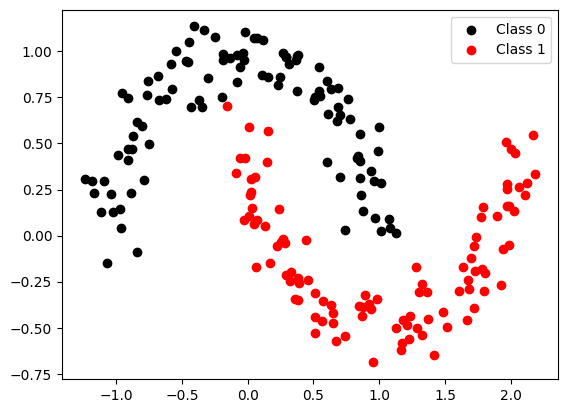

In [527]:
from sklearn import cluster, datasets, mixture

#use this seed in your solution
np.random.seed(16543677)


# Generate concentric circles
# factor determines the distance between the inner and outer circles
X, y = noisy_moons = datasets.make_moons(n_samples=200, noise=0.1)

# Plot data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], color='black', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1')
plt.legend()
plt.show()


### Part A: K-means Clustering (10 points)
**Questions:**
1. Use sklearn's k-means clustering algorithm to divide the data given above ($X$) into two clusters. Plot the result and show the cluster centres that you found.
2. Experiment with different starting points (`init='random'`) and number of clusters, e.g. 3, 4, 5. Plot the results.
3. Write your observations and interpret them using your theoretical knowledge from lectures and books.

### Part B: GMMs as Density Estimators (10 points)
**Questions:**
1. Now use a Gaussian Mixture Model (GMM) for clustering the same two moon data. Try two clusters and plot your results. GMMs also provides you probabilities (of a sample belonging to a cluster). Print those of a few samples using [*pandas.DataFrame*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
2. Increase the number of components of your GMM model, e.g., 3, 4, and 5. Plot the results.
3. Use a metric to choose the number of components in a principled way. *Hint: check [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion) or [AIC](https://en.wikipedia.org/wiki/Akaike_information_criterion)*. Plot the result of the optimal number of components and print the probabilities of some samples.
4. Write your observations and interpret them using your theoretical knowledge from lectures and books.

## Question 3: Neural Networks (Marks: 20 Points)

Classification is a supervised learning technique where we want to predict the class or label of new data points based on a training dataset that has labels already. In this question, we will implementation a DNN classification with PyTorch.

**Example:**

PyTorch is an open-source machine learning framework, which is widely used for building and training lightweight deep learning models. For those who are new to PyTorch or willing to delve into more technical content, it is highly recommended to explore the official [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html).

We will exhibit how to build a neural network with PyTorch. The following codes provide a framework to define a DNN. For more details and advanced tricks, here are some helpful resources
<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1)<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2)<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3).

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) [Build a neural network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) [Use CNN to classify digit images](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html).

<a name="cite_note-3"></a> [<sup>[3]</sup>](#cite_ref-3) [Useful APIs](https://pytorch.org/docs/stable/nn.html).

1. Finish the implementation of the DNN class:
  (a) `init` method defines the model structure: create linear layers for the model and the number of node of each layer should match the `layer_list`.
  (b) `forward` method performs the forward-propagation process of DNN: pass the input `x` through each layer in the model sequentially and apply activation function.

In [528]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class DNN(torch.nn.Module):
    def __init__(self, input_dim, layer_list):
        super(DNN, self).__init__()

        # Store layers in a ModuleList
        self.layers = nn.ModuleList()

        # First layer
        prev_dim = input_dim

        for layer_dim in layer_list:
            self.layers.append(nn.Linear(prev_dim, layer_dim))
            prev_dim = layer_dim

    def forward(self, input):
        x = input

        # Apply each layer sequentially
        for i, layer in enumerate(self.layers):
            x = layer(x)

            # Apply activation to all layers except the last one
            if i < len(self.layers) - 1:
                x = F.relu(x)

        return x

**Questions:** DNN Classification

In this question, we use the same data given in Question 2, with `n_samples=400` and `noise=0.2`. The following codes divide the data to training and test sets using the default ratio.

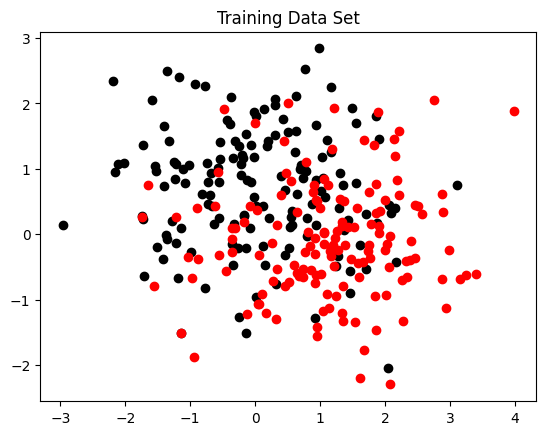

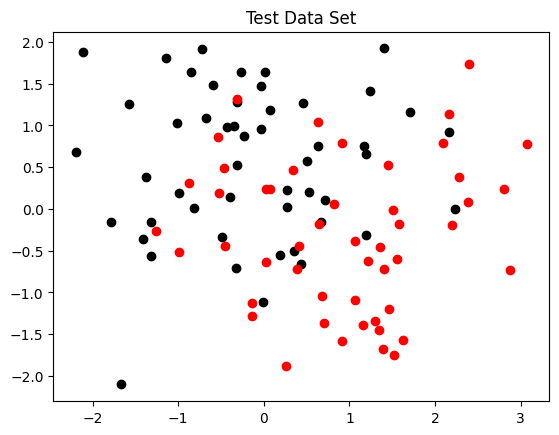

In [529]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.8)

X_train, X_test, y_train, y_test =  train_test_split(X, y)

# Visualize the training data set
order_ind = np.argsort(y_train)
Xm1_train = X_train[order_ind[0:150]]
Xm2_train = X_train[order_ind[151:300]]

plt.figure()
plt.scatter(Xm1_train[:,0], Xm1_train[:,1], color='black')
plt.scatter(Xm2_train[:,0], Xm2_train[:,1], color='red')
plt.title("Training Data Set")
plt.show()

# Visualize the test data set
order_ind = np.argsort(y_test)
Xm1_test = X_test[order_ind[0:50]]
Xm2_test = X_test[order_ind[51:100]]

plt.figure()
plt.scatter(Xm1_test[:,0], Xm1_test[:,1], color='black')
plt.scatter(Xm2_test[:,0], Xm2_test[:,1], color='red')
plt.title("Test Data Set")
plt.show()

2. Train and evaluate a DNN using the class written in Question 3.1. Start with an example structure (8, 4, 1) and then try different DNN structures. For alternative choices, you can use only one hidden layer or many more layers. You can also use different activation functions as long as you end up with a single node binary classifier. Try also different optimizers, training learning rate, and loss functions. Which one works best? Try, observe, and discuss!

In [530]:
# Convert given datasets to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

In [531]:
def train_model(model, lr=0.01, epochs=1000, optimizer_name="adam"):

    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

In [532]:
def evaluate_model(model):
    model.eval()

    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

    acc = accuracy_score(y_test, preds.numpy())
    print(f"Test Accuracy: {acc:.4f}")

    return acc

In [533]:
## A Baseline: (8:4:1)
model = DNN(2, [8, 4, 1])
train_model(model)
evaluate_model(model)

Epoch 0, Loss: 0.6777
Epoch 200, Loss: 0.4930
Epoch 400, Loss: 0.4868
Epoch 600, Loss: 0.4793
Epoch 800, Loss: 0.4748
Test Accuracy: 0.7300


0.73

In [534]:
## Single Hidden layer
model = DNN(2, [8, 1])
train_model(model)
evaluate_model(model)

Epoch 0, Loss: 0.6831
Epoch 200, Loss: 0.5061
Epoch 400, Loss: 0.5041
Epoch 600, Loss: 0.5035
Epoch 800, Loss: 0.5008
Test Accuracy: 0.7500


0.75

In [535]:
## Deeper Neural Network
model = DNN(2, [16, 8, 4, 1])
train_model(model)
evaluate_model(model)

Epoch 0, Loss: 0.6886
Epoch 200, Loss: 0.4827
Epoch 400, Loss: 0.4586
Epoch 600, Loss: 0.4528
Epoch 800, Loss: 0.4489
Test Accuracy: 0.7000


0.7

In [536]:
## Different Optimizer
model = DNN(2, [8, 4, 1])
train_model(model, optimizer_name="sgd")
evaluate_model(model)

Epoch 0, Loss: 0.6752
Epoch 200, Loss: 0.6379
Epoch 400, Loss: 0.5946
Epoch 600, Loss: 0.5597
Epoch 800, Loss: 0.5364
Test Accuracy: 0.7200


0.72

In [537]:
## Different learning rate
train_model(model, lr=0.001)
evaluate_model(model)

Epoch 0, Loss: 0.5246
Epoch 200, Loss: 0.5056
Epoch 400, Loss: 0.5014
Epoch 600, Loss: 0.4985
Epoch 800, Loss: 0.4968
Test Accuracy: 0.7200


0.72

It can be seen that single hidden layer and three hidden layers are not performing well as two hidden layers, which indicates there is an underfit for single hidden layer and overfit for three hidden layer.

Also, Adam optimiser performed better than SGD in this scenario.

As for the learning rate, 0.001 has a slightly better performance than 0.01 but it took longer time for 0.001 learning rate to converge.


3. For the best combination (structure, activation function, optimizer, learning rate, and loss function) you managed to find in Question 3.2, investigate the impact of training epochs on DNN performance. Observe the difference between training and test set loss and accuracy. Interpret your results. What does a big difference between training and test set performance mean? Note: if the training and test accuracy are the same, increase the `noise` from 0.2 to a higher value.

In [538]:
def train_with_tracking(model, epochs=2000, lr=0.01):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ---- EVALUATE ----
        model.eval()
        with torch.no_grad():
            # Train metrics
            train_logits = model(X_train_t)
            train_loss = criterion(train_logits, y_train_t).item()
            train_probs = torch.sigmoid(train_logits)
            train_preds = (train_probs > 0.5).float()
            train_acc = accuracy_score(y_train, train_preds.numpy())

            # Test metrics
            test_logits = model(X_test_t)
            test_loss = criterion(test_logits, y_test_t).item()
            test_probs = torch.sigmoid(test_logits)
            test_preds = (test_probs > 0.5).float()
            test_acc = accuracy_score(y_test, test_preds.numpy())

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 200 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}")
            print(f"Epoch {epoch}: Train Lost={train_loss:.3f}, Test Lost={test_loss:.3f}")

    return train_losses, test_losses, train_accs, test_accs

In [539]:
model = model = DNN(2, [8, 4, 1]) # the best structure
train_losses, test_losses, train_accs, test_accs = train_with_tracking(model)

Epoch 0: Train Acc=0.497, Test Acc=0.510
Epoch 0: Train Lost=0.763, Test Lost=0.752
Epoch 200: Train Acc=0.760, Test Acc=0.740
Epoch 200: Train Lost=0.506, Test Lost=0.525
Epoch 400: Train Acc=0.760, Test Acc=0.740
Epoch 400: Train Lost=0.500, Test Lost=0.512
Epoch 600: Train Acc=0.763, Test Acc=0.770
Epoch 600: Train Lost=0.499, Test Lost=0.510
Epoch 800: Train Acc=0.770, Test Acc=0.760
Epoch 800: Train Lost=0.495, Test Lost=0.509
Epoch 1000: Train Acc=0.770, Test Acc=0.770
Epoch 1000: Train Lost=0.484, Test Lost=0.509
Epoch 1200: Train Acc=0.777, Test Acc=0.760
Epoch 1200: Train Lost=0.481, Test Lost=0.515
Epoch 1400: Train Acc=0.773, Test Acc=0.750
Epoch 1400: Train Lost=0.476, Test Lost=0.508
Epoch 1600: Train Acc=0.773, Test Acc=0.750
Epoch 1600: Train Lost=0.474, Test Lost=0.510
Epoch 1800: Train Acc=0.777, Test Acc=0.740
Epoch 1800: Train Lost=0.473, Test Lost=0.512


It can be observed that there is a difference between training and test accuracy, which indicates the model may have the overfit issue, and the model is not generalised for unseen data.

4. Try other advanced types of neural networks.

Epoch 0: Train Acc=0.507, Test Acc=0.490
Epoch 200: Train Acc=0.763, Test Acc=0.760
Epoch 400: Train Acc=0.763, Test Acc=0.770
Epoch 600: Train Acc=0.773, Test Acc=0.740
Epoch 800: Train Acc=0.777, Test Acc=0.750
Epoch 1000: Train Acc=0.773, Test Acc=0.730
Epoch 1200: Train Acc=0.767, Test Acc=0.760
Epoch 1400: Train Acc=0.783, Test Acc=0.760
Epoch 1600: Train Acc=0.770, Test Acc=0.740
Epoch 1800: Train Acc=0.777, Test Acc=0.740

Final Performance:
Train Accuracy: 0.7733
Test Accuracy:  0.7400


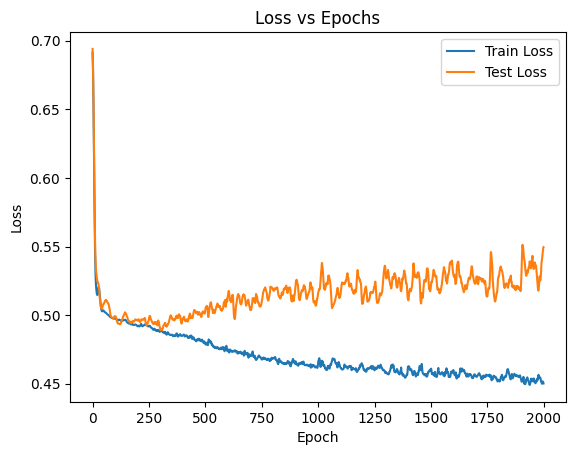

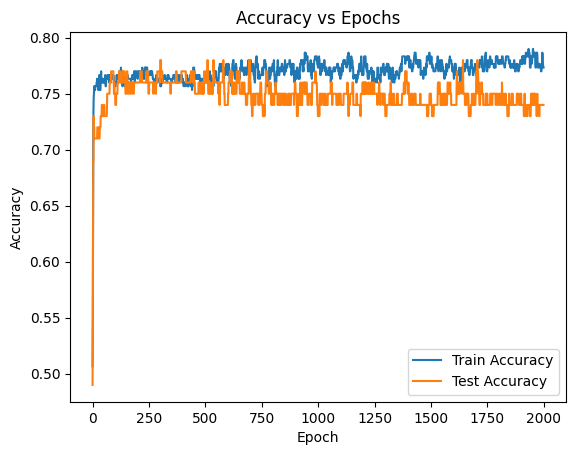

In [540]:
## The advanced model used is Deeper MLP with Regularization (Improved DNN)
# ===== Model Definition =====
class AdvancedDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)  # output layer (logits)
        )

    def forward(self, x):
        return self.net(x)

# ===== Training Function =====
def train_model(model, epochs=2000, lr=0.01):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ---- Evaluate ----
        model.eval()
        with torch.no_grad():
            # Train metrics
            train_logits = model(X_train_t)
            train_loss = criterion(train_logits, y_train_t).item()
            train_probs = torch.sigmoid(train_logits)
            train_preds = (train_probs > 0.5).float()
            train_acc = accuracy_score(y_train, train_preds.numpy())

            # Test metrics
            test_logits = model(X_test_t)
            test_loss = criterion(test_logits, y_test_t).item()
            test_probs = torch.sigmoid(test_logits)
            test_preds = (test_probs > 0.5).float()
            test_acc = accuracy_score(y_test, test_preds.numpy())

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 200 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}")

    return train_losses, test_losses, train_accs, test_accs

# ===== Run Training =====
model = AdvancedDNN(input_dim=2)
train_losses, test_losses, train_accs, test_accs = train_model(model)

# ===== Final Evaluation =====
print("\nFinal Performance:")
print(f"Train Accuracy: {train_accs[-1]:.4f}")
print(f"Test Accuracy:  {test_accs[-1]:.4f}")

# ===== Plot Loss =====
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ===== Plot Accuracy =====
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Question 5: Generative Modeling with Convolutional Variational Autoencoders (VAEs) (Marks: 3 + 5 + 7 + 5 = 20 Points)

**Background:**
A Variational Autoencoder (VAE) is a generative model that treats image generation as a reconstruction task through a compressed "bottleneck." Unlike standard Autoencoders that map an input $x$ to a single fixed point $z\in\mathbb{R}^d$ ($d$ is the latent space dimension), a VAE uses a probabilistic approach to ensure the compressed space is continuous and suitable for sampling.

The VAE consists of two neural networks (NNs) named as encoder and decoder:
* The encoder compresses the input image $x$ into a latent representation. Instead of learning a single point $z$, the encoder learns the mean $\mu=(\mu_1,\cdots,\mu_d)\in\mathbb{R}^d$ and variance $\sigma^2=(\sigma^2_1,\cdots,\sigma^2_d)\in\mathbb{R}^d$ of the latent distribution $q(z|x)$. We assume a diagonal Gaussian distribution $\mathcal{N}(\mu,\text{diag}(\sigma^2))$ where each entry of $z$ is independent of each other. The hidden layer feature $z\in\mathbb{R}^d$ is sampled from this distribution.
* The decoder takes the latent vector $z$ and attempts to reconstruct the original input. The output is the reconstructed image $\hat{x}$.

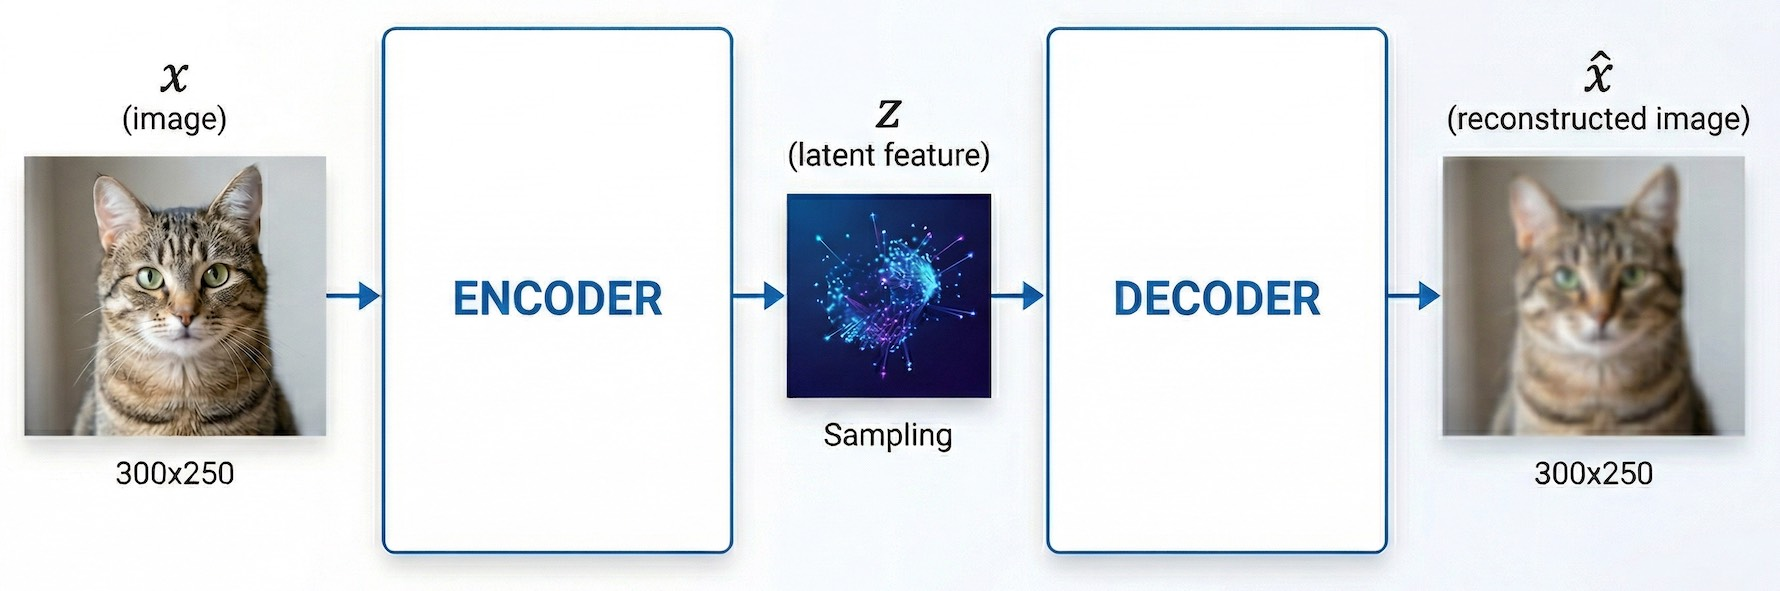

To train the NN-based encoder and decoder, we define the loss function for image reconstructrion. Unlike standard autoencoders that use simple Mean Squared Error (MSE), VAEs are trained by maximizing the Evidence Lower Bound (ELBO), which is equivalent to minimizing the negative ELBO. The loss function consists of two competing terms:
1.  **Reconstruction Loss:** Measures the pixel-wise difference between input $x$ and output $\hat{x}$. We can use MSE (or Binary Cross Entropy) to measure the pixel-wise difference.
2.  **KL Divergence ($D_{KL}$):** Acts as a regularizer. It calculate the distance between the approximated distribution of $z$ (which is a diagonal Gaussian parameterized by the encoder's outputs $\mu$ and $\sigma^2$) and a standard normal distribution $\mathcal{N}(\mathbf{0},\mathbf{I}_d)$.

### Part A: Mathematical Foundation and the Reparameterization Trick (3 Points)
**Questions:**
1. Explain conceptually and algebraically why we cannot use standard back-propagation if we sample $z$ directly as $z\sim\mathcal{N}(\mu, \sigma^2)$ during the training process of a VAE. How does the reparameterization trick $z=\mu+\sigma\odot \epsilon$ solve the problem of using back-propagation? ($\odot$ represents element-wise multiplication and $\epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$)
2. Let's look at a simple toy example. Suppose our encoder outputs a scalar $\mu = 2$ and $\sigma = 1$. We sample a value $\epsilon = 0.5$ from the standard normal distribution $\mathcal{N}(0, 1)$. Our loss function is purely a toy reconstruction loss defined as $L = (z - 5)^2$. Use the reparameterization trick to calculate the gradient of the loss with respect to both $\mu$ and $\sigma$.

### Part A answer

#### A.1
##### Why standard backpropagation cannot be used

Because direct sampling:
$$
z \sim \mathcal{N}(\mu, \sigma^2)
$$
is a stochastic operation. This leads to the following issues:

- Sampling is not differentiable with respect to $\mu$ and $\sigma$
- There is no deterministic function linking encoder outputs to $z$

Hence, gradients cannot flow through the sampling step and the partial derivative below cannot be computed:
$$
\frac{\partial \mathcal{L}}{\partial \mu}, \quad \frac{\partial \mathcal{L}}{\partial \sigma}
$$

---

##### Why reparameterization trick works

Because for reparameterization trick:
$$
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

Points below are the justifications for it to work
- $\epsilon$ is independent of the model parameters
- $\mu$ and $\sigma$ are deterministic outputs of the encoder
- The stochasticity is moved outside the network

Now $z$ becomes a differentiable function:
$$
z(\mu, \sigma, \epsilon) = \mu + \sigma \odot \epsilon
$$

Thus, gradients can be computed as:
- $\frac{\partial z}{\partial \mu} = 1$
- $\frac{\partial z}{\partial \sigma} = \epsilon$

---

##### Conclusion

The reparameterization trick converts a stochastic sampling operation into a differentiable computation by isolating randomness in $\epsilon$. This allows standard backpropagation to be used for training VAEs end-to-end.

---
---


#### A.2

##### Gradient loss of using Reparameterization Trick

The parameter below are given:
- $\mu = 2$, $\sigma = 1$
- $\epsilon = 0.5$
- Reparameterization:
  $$
  z = \mu + \sigma \epsilon
  $$
- Loss function:
  $$
  L = (z - 5)^2
  $$


##### Step 1: Compute $z$

$$
z = 2 + (1)(0.5) = 2.5
$$


##### Step 2: Compute loss

$$
L = (2.5 - 5)^2 = (-2.5)^2 = 6.25
$$


##### Step 3: Compute gradient of loss w.r.t. $z$

Using chain rule:
$$
\frac{\partial L}{\partial z} = 2(z - 5)
$$

Substituting $z = 2.5$:
$$
\frac{\partial L}{\partial z} = 2(2.5 - 5) = -5
$$


##### Step 4: Reparameterization derivatives

From:
$$
z = \mu + \sigma \epsilon
$$

It can get:
$$
\frac{\partial z}{\partial \mu} = 1, \quad \frac{\partial z}{\partial \sigma} = \epsilon
$$


##### Step 5: Gradient w.r.t. $\mu$

$$
\frac{\partial L}{\partial \mu}
= \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial \mu}
= (-5)(1) = -5
$$


##### Step 6: Gradient w.r.t. $\sigma$

$$
\frac{\partial L}{\partial \sigma}
= \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial \sigma}
= (-5)(0.5) = -2.5
$$


##### Final Answer

$$
\frac{\partial L}{\partial \mu} = -5, \quad \frac{\partial L}{\partial \sigma} = -2.5
$$


### Part B: Designing a Convolutional VAE for CIFAR-10 (5 Points)
**Questions:**
Using PyTorch, implement a `ConvVAE` class designed for the CIFAR-10 dataset (where inputs are 3 channels, 32x32 pixels). To avoid dimension mismatch errors, you can use the following specific architecture:

1. **Encoder:** Three `Conv2d` layers with kernel size 3.
    * Layer 1: 3 input channels $\rightarrow$ 16 output channels (with ReLU).
    * Layer 2: 16 input channels $\rightarrow$ 32 output channels (with ReLU).
    * Layer 3: 32 input channels $\rightarrow$ 64 output channels (with ReLU).
    * Apply a ReLU activation after each convolutional layer.
2. **Latent Mapping:** Flatten the output of the final convolutional layer and map it using two separate `Linear` layers to `mu` and `log_var`. The latent space dimension should be parameterized by an initialization variable `latent_dim`.
3. **Reparameterization:** A `reparameterize` method implementing the trick discussed in Part A.
4. **Decoder:** Map the latent vector back to a tensor of shape `(batch_size, 64, 4, 4)` using a `Linear` layer and ReLU. Then use three `ConvTranspose2d` layers to upsample back to 3x32x32.
    * Use kernel size 3 for all three layers.
    * Layer 1: 64 $\rightarrow$ 32 channels (with ReLU).
    * Layer 2: 32 $\rightarrow$ 16 channels (with ReLU).
    * Layer 3: 16 $\rightarrow$ 3 channels.
    * Apply a `Sigmoid` activation to the final output so pixel values are between 0 and 1.
5. **Forward Pass:** A `forward` method seamlessly connecting the encoder, reparameterization, and decoder.

### Part B answer

In [541]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms


class ConvVAE(nn.Module):
    def __init__(self, latent_dim):
        super(ConvVAE, self).__init__()

        # -----------------------
        # Encoder
        # -----------------------
        self.enc1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)   # 32 -> 16
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)  # 16 -> 8
        self.enc3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)  # 8 -> 4

        # After conv: (64, 4, 4)
        self.flatten_dim = 64 * 4 * 4

        # Latent space
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # -----------------------
        # Decoder
        # -----------------------
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.dec1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)  # 4 -> 8
        self.dec2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)  # 8 -> 16
        self.dec3 = nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1)   # 16 -> 32

    # -----------------------
    # Encoder forward
    # -----------------------
    def encode(self, x):
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))

        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)

        return mu, log_var

    # -----------------------
    # Reparameterization trick
    # -----------------------
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    # -----------------------
    # Decoder forward
    # -----------------------
    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 64, 4, 4)

        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = torch.sigmoid(self.dec3(x))

        return x

    # -----------------------
    # Full forward pass
    # -----------------------
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decode(z)
        return recon_x, mu, log_var

### Part C: The ELBO Loss and Training Loop (7 Points)

**Questions:**
1. Derive the analytical formula for the KL divergence between a univariate Gaussian approximate posterior $q(z|x) = \mathcal{N}(z;\mu,\text{diag}(\sigma^2))$ and a standard normal prior $p(z) = \mathcal{N}(\mathbf{0},\mathbf{I}_d)$. The definition of KL divergence is given by
$$
D_{KL}(q(z|x)\|p(z)) = \int_{\mathcal{Z}}q(z|x)\log\frac{q(z|x)}{p(z)}dz.
$$
Note: For a multi-variate Gaussian distribution, if the dimensions are independent, the total KL divergence is simply the sum of Kl divergence for each dimension.
2. Write a Python function `vae_loss(recon_x, x, mu, log_var)` that computes the negative ELBO (Reconstruction Loss + KL Divergence). Use MSE with `reduction='sum'` for the reconstruction part.
3. Write a Python function `train(model, train_loader, optimizer, epochs)` that trains the model in a training loop for a given number of epochs, and prints out the training loss for each epoch.
4. Write a Python script that execute the training process:
    * **Data Pre-processing:** Ensure you correctly process the image so they are compatible with your decoder's output.
    * **Training:** Train the model for **25 epochs** using learning rate $0.001$. Set the latent space dimension $d=128$. Print the average loss for each epoch.

### Part C answer

#### C.1

##### The Gaussian densities

For a univariate Gaussian:

$$
q(z|x) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{(z - \mu)^2}{2\sigma^2}\right)
$$

$$
p(z) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{z^2}{2}\right)
$$


##### The log ratio

$$
\log \frac{q(z|x)}{p(z)}
= -\frac{1}{2}\log \sigma^2 - \frac{(z - \mu)^2}{2\sigma^2} + \frac{z^2}{2}
$$


##### The expectation w.r.t. $q(z|x)$

$$
D_{KL} = \mathbb{E}_{q}\left[\log \frac{q(z|x)}{p(z)}\right]
$$

Compute each term:

- $\mathbb{E}_q[(z - \mu)^2] = \sigma^2$
- $\mathbb{E}_q[z^2] = \mu^2 + \sigma^2$

Substitute:

$$
D_{KL} = -\frac{1}{2}\log \sigma^2 - \frac{1}{2} + \frac{1}{2}(\mu^2 + \sigma^2)
$$


##### Final simplified form

$$
D_{KL} = \frac{1}{2}\left(\mu^2 + \sigma^2 - \log \sigma^2 - 1\right)
$$


##### Extension to multivariate case

For independent dimensions:

$$
D_{KL}(q(z|x)\|p(z)) =
\frac{1}{2}\sum_{i=1}^{d}
\left(\mu_i^2 + \sigma_i^2 - \log \sigma_i^2 - 1\right)
$$


##### Final Answer

$$
D_{KL} = \frac{1}{2}\sum_{i=1}^{d}
\left(\mu_i^2 + \sigma_i^2 - \log \sigma_i^2 - 1\right)
$$

#### C.2

In [542]:
def vae_loss(recon_x, x, mu, log_var):
    '''
    This function takes the input image and the reconstructed image,
    calculates and outputs the loss function for VAE.
    '''

    # -----------------------
    # Reconstruction loss (MSE)
    # -----------------------
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # -----------------------
    # KL divergence
    # -----------------------
    kl_loss = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    )

    # -----------------------
    # Total ELBO loss (negative ELBO)
    # -----------------------
    loss = recon_loss + kl_loss

    return loss

#### C.3

In [543]:
def train(model, train_loader, lr, epochs, device):
    '''
    Training loop for ConvVAE
    '''

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, _ in train_loader:
            x = x.to(device)

            # -----------------------
            # Forward pass
            # -----------------------
            recon_x, mu, log_var = model(x)

            # -----------------------
            # Compute loss
            # -----------------------
            loss = vae_loss(recon_x, x, mu, log_var)

            # -----------------------
            # Backpropagation
            # -----------------------
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")

#### C.4

In [544]:
# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
print(device)
# -----------------------
# Data Pre-processing
# -----------------------
# Convert images to tensor and ensure values are in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# -----------------------
# Model initialization
# -----------------------
latent_dim = 128
model = ConvVAE(latent_dim).to(device)

# -----------------------
# Training setup
# -----------------------
lr = 0.001
epochs = 25

# -----------------------
# Training loop
# -----------------------
model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    total_loss = 0.0

    for x, _ in train_loader:
        x = x.to(device)

        # Forward pass
        recon_x, mu, log_var = model(x)

        # Loss computation
        loss = vae_loss(recon_x, x, mu, log_var)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] | Average Loss: {avg_loss:.4f}")

cuda


C:\Users\Charl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch [1/25] | Average Loss: 125.6298
Epoch [2/25] | Average Loss: 91.6656
Epoch [3/25] | Average Loss: 83.0186
Epoch [4/25] | Average Loss: 80.1167
Epoch [5/25] | Average Loss: 78.9850
Epoch [6/25] | Average Loss: 78.2552
Epoch [7/25] | Average Loss: 77.9049
Epoch [8/25] | Average Loss: 77.5067
Epoch [9/25] | Average Loss: 77.1853
Epoch [10/25] | Average Loss: 76.9175
Epoch [11/25] | Average Loss: 76.7643
Epoch [12/25] | Average Loss: 76.6452
Epoch [13/25] | Average Loss: 76.4584
Epoch [14/25] | Average Loss: 76.3054
Epoch [15/25] | Average Loss: 76.1873
Epoch [16/25] | Average Loss: 76.1245
Epoch [17/25] | Average Loss: 76.0396
Epoch [18/25] | Average Loss: 75.8572
Epoch [19/25] | Average Loss: 75.7426
Epoch [20/25] | Average Loss: 75.6233
Epoch [21/25] | Average Loss: 75.5205
Epoch [22/25] | Average Loss: 75.4680
Epoch [23/25] | Average Loss: 75.4012
Epoch [24/25] | Average Loss: 75.3768
Epoch [25/25] | Average Loss: 75.2533


### Part D: Investigating the Compression vs. Performance Trade-off (5 Points)
**Questions:**
The VAE maps high-dimensional CIFAR-10 images (3x32x32 = 3072 dimensions) into a smaller latent representation. The `latent_dim` size controls the "compression rate."
Write a script to investigate how the size of this bottleneck affects the model's ability to reconstruct images.
1. Write a Python function `test()` to evaluate the average reconstruction loss **(only MSE loss)** on the CIFAR-10 **test set**.
2. Instantiate and train three completely separate VAE models using `latent_dim` values of 16, 64, 128, and 256. Train each model for 25 epochs. Use the `test` function to evaluate performance for each trained model. For each trained model, select one image from the test dataset, plot is togehter with its corresponding reconstructed image.
3. Calculate the compression ratio for each latent dimension (the ratio between the size of latent representation $z$ and the input image $x$). Assume an original CIFAR-10 image is 32x32 pixels, 3 channels, where each pixel is an integer value ranging in [0,255]. Assume the latent representation $z$ uses 32-bit floats. Plot the test loss (y-axis) versus the compression ratio (x-axis) using `matplotlib`.
4. Provide a brief discussion on the observed trade-off between the compression rate and reconstruction performance. Why does the loss behave this way?

### Part D answer

#### D.1

In [545]:
def test(model, test_loader, device):
    '''
    Evaluate average reconstruction loss (MSE only) on the test set.

    Inputs:
        model: trained ConvVAE model
        test_loader: DataLoader for CIFAR-10 test set
        device: 'cuda' or 'cpu'

    Returns:
        avg_mse_loss: average MSE reconstruction loss over dataset
    '''

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)

            # Forward pass
            recon_x, _, _ = model(x)

            # Reconstruction loss (MSE only)
            loss = F.mse_loss(recon_x, x, reduction='sum')

            total_loss += loss.item()

    # Average per sample
    avg_mse_loss = total_loss / len(test_loader.dataset)

    return avg_mse_loss

#### D.2


Training VAE with latent_dim = 16
Epoch [1/25] | Loss: 120.8315
Epoch [2/25] | Loss: 85.7461
Epoch [3/25] | Loss: 80.3787
Epoch [4/25] | Loss: 79.5075
Epoch [5/25] | Loss: 79.1568
Epoch [6/25] | Loss: 78.8774
Epoch [7/25] | Loss: 78.6846
Epoch [8/25] | Loss: 78.5216
Epoch [9/25] | Loss: 78.3996
Epoch [10/25] | Loss: 78.2647
Epoch [11/25] | Loss: 78.1489
Epoch [12/25] | Loss: 78.1110
Epoch [13/25] | Loss: 77.9778
Epoch [14/25] | Loss: 77.8850
Epoch [15/25] | Loss: 77.7774
Epoch [16/25] | Loss: 77.7508
Epoch [17/25] | Loss: 77.7060
Epoch [18/25] | Loss: 77.6275
Epoch [19/25] | Loss: 77.5697
Epoch [20/25] | Loss: 77.5232
Epoch [21/25] | Loss: 77.4773
Epoch [22/25] | Loss: 77.4009
Epoch [23/25] | Loss: 77.4183
Epoch [24/25] | Loss: 77.3279
Epoch [25/25] | Loss: 77.2967
Test MSE Loss (latent_dim=16): 59.0657


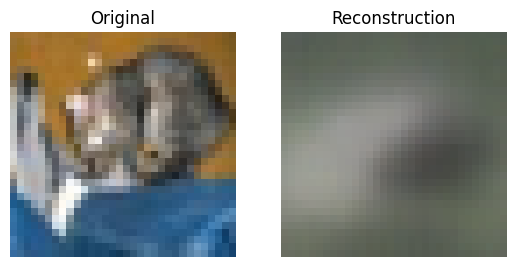


Training VAE with latent_dim = 64
Epoch [1/25] | Loss: 124.3436
Epoch [2/25] | Loss: 88.7087
Epoch [3/25] | Loss: 82.3947
Epoch [4/25] | Loss: 79.4559
Epoch [5/25] | Loss: 78.2551
Epoch [6/25] | Loss: 77.8043
Epoch [7/25] | Loss: 77.4264
Epoch [8/25] | Loss: 77.0095
Epoch [9/25] | Loss: 76.7880
Epoch [10/25] | Loss: 76.5120
Epoch [11/25] | Loss: 76.3260
Epoch [12/25] | Loss: 76.1467
Epoch [13/25] | Loss: 75.9903
Epoch [14/25] | Loss: 75.8700
Epoch [15/25] | Loss: 75.7804
Epoch [16/25] | Loss: 75.6738
Epoch [17/25] | Loss: 75.4775
Epoch [18/25] | Loss: 75.3292
Epoch [19/25] | Loss: 75.2176
Epoch [20/25] | Loss: 75.1783
Epoch [21/25] | Loss: 75.1210
Epoch [22/25] | Loss: 74.9971
Epoch [23/25] | Loss: 74.9266
Epoch [24/25] | Loss: 74.8866
Epoch [25/25] | Loss: 74.8300
Test MSE Loss (latent_dim=64): 52.2389


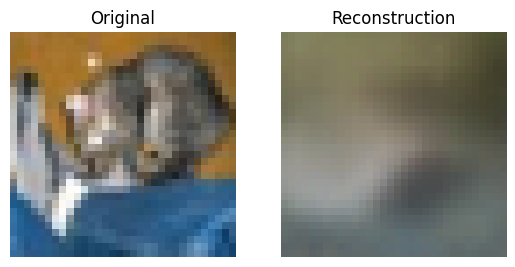


Training VAE with latent_dim = 128
Epoch [1/25] | Loss: 127.7311
Epoch [2/25] | Loss: 89.2415
Epoch [3/25] | Loss: 82.3293
Epoch [4/25] | Loss: 79.9669
Epoch [5/25] | Loss: 78.9513
Epoch [6/25] | Loss: 78.3677
Epoch [7/25] | Loss: 77.9284
Epoch [8/25] | Loss: 77.5477
Epoch [9/25] | Loss: 77.2193
Epoch [10/25] | Loss: 76.9334
Epoch [11/25] | Loss: 76.6675
Epoch [12/25] | Loss: 76.3696
Epoch [13/25] | Loss: 76.2356
Epoch [14/25] | Loss: 76.0326
Epoch [15/25] | Loss: 75.8491
Epoch [16/25] | Loss: 75.7437
Epoch [17/25] | Loss: 75.6354
Epoch [18/25] | Loss: 75.5742
Epoch [19/25] | Loss: 75.4917
Epoch [20/25] | Loss: 75.4037
Epoch [21/25] | Loss: 75.3702
Epoch [22/25] | Loss: 75.3191
Epoch [23/25] | Loss: 75.2305
Epoch [24/25] | Loss: 75.1712
Epoch [25/25] | Loss: 75.1812
Test MSE Loss (latent_dim=128): 52.4065


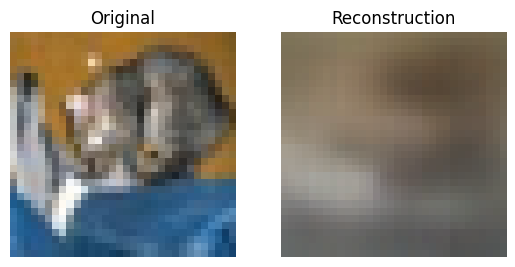


Training VAE with latent_dim = 256
Epoch [1/25] | Loss: 127.4853
Epoch [2/25] | Loss: 94.8550
Epoch [3/25] | Loss: 84.3451
Epoch [4/25] | Loss: 80.8286
Epoch [5/25] | Loss: 79.6465
Epoch [6/25] | Loss: 79.0042
Epoch [7/25] | Loss: 78.5586
Epoch [8/25] | Loss: 78.2497
Epoch [9/25] | Loss: 77.9437
Epoch [10/25] | Loss: 77.7087
Epoch [11/25] | Loss: 77.4430
Epoch [12/25] | Loss: 77.2793
Epoch [13/25] | Loss: 76.9797
Epoch [14/25] | Loss: 76.7952
Epoch [15/25] | Loss: 76.6067
Epoch [16/25] | Loss: 76.4219
Epoch [17/25] | Loss: 76.2063
Epoch [18/25] | Loss: 76.1142
Epoch [19/25] | Loss: 75.9652
Epoch [20/25] | Loss: 75.8781
Epoch [21/25] | Loss: 75.8376
Epoch [22/25] | Loss: 75.7193
Epoch [23/25] | Loss: 75.6648
Epoch [24/25] | Loss: 75.6108
Epoch [25/25] | Loss: 75.5665
Test MSE Loss (latent_dim=256): 52.7799


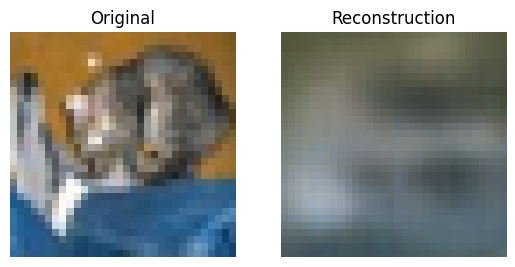


Summary of Results:
Latent Dim: 16 | Test Loss: 59.0657
Latent Dim: 64 | Test Loss: 52.2389
Latent Dim: 128 | Test Loss: 52.4065
Latent Dim: 256 | Test Loss: 52.7799


In [546]:
# -----------------------
# Helper: visualize reconstruction
# -----------------------
def show_reconstruction(model, dataset, device):
    model.eval()

    # take one sample
    x, _ = dataset[0]
    x = x.unsqueeze(0).to(device)  # shape: (1, 3, 32, 32)

    with torch.no_grad():
        recon_x, _, _ = model(x)

    # move to cpu for plotting
    x = x.squeeze(0).cpu().permute(1, 2, 0).numpy()
    recon_x = recon_x.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # plot
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(x)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(recon_x)
    axes[1].set_title("Reconstruction")
    axes[1].axis("off")

    plt.show()

# -----------------------
# Test dataset
# -----------------------
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# -----------------------
# Test DataLoader
# -----------------------
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# -----------------------
# Experiment settings
# -----------------------
latent_dims = [16, 64, 128, 256]
epochs = 25
lr = 0.001

results = {}

for latent_dim in latent_dims:
    print(f"\nTraining VAE with latent_dim = {latent_dim}")

    # Initialize model
    model = ConvVAE(latent_dim).to(device)

    # Train model
    train(model, train_loader, lr, epochs, device)

    # Evaluate model
    test_loss = test(model, test_loader, device)
    results[latent_dim] = test_loss

    print(f"Test MSE Loss (latent_dim={latent_dim}): {test_loss:.4f}")

    # Show reconstruction
    show_reconstruction(model, test_dataset, device)


# -----------------------
# Print summary
# -----------------------
print("\nSummary of Results:")
for k, v in results.items():
    print(f"Latent Dim: {k} | Test Loss: {v:.4f}")

#### D.3

#### Key Idea

- Original CIFAR-10 image size:
$$
32 \times 32 \times 3 = 3072 \text{ values}
$$

- Each pixel is stored as an 8-bit integer:
$$
\text{Total input size} = 3072 \times 8 = 24576 \text{ bits}
$$

---

#### Latent Representation

- Latent vector size = $d$ (latent\_dim)
- Each value is a 32-bit float:

$$
\text{Latent size} = d \times 32 \text{ bits}
$$

---

#### Compression Ratio

$$
\text{Compression Ratio} =
\frac{\text{Latent size}}{\text{Input size}} =
\frac{d \times 32}{3072 \times 8}
$$

---

#### Simplified Form

$$
\text{Compression Ratio} = \frac{d}{768}
$$

---

#### Final Answer

$$
\boxed{
\text{Compression Ratio} = \frac{d}{768}
}
$$

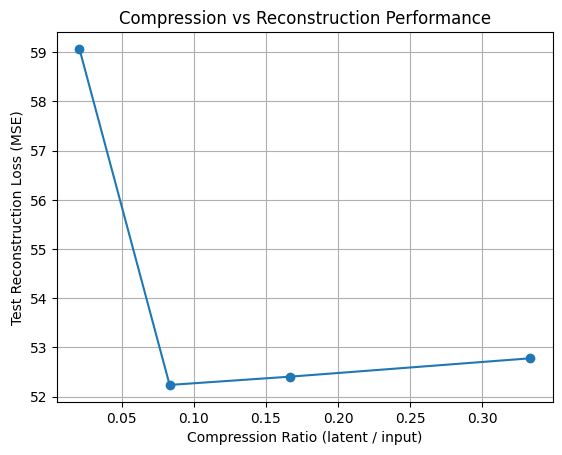

In [547]:
# Given latent dimensions
latent_dims = [16, 64, 128, 256]

# Input size (in bits)
input_bits = 32 * 32 * 3 * 8  # = 24576 bits

compression_ratios = []
test_losses = []

# Assume results dictionary from previous experiment
# results = {16: loss1, 64: loss2, ...}

for d in latent_dims:
    latent_bits = d * 32  # float32

    compression_ratio = latent_bits / input_bits
    compression_ratios.append(compression_ratio)

    test_losses.append(results[d])

# -----------------------
# Plot
# -----------------------
plt.figure()

plt.plot(compression_ratios, test_losses, marker='o')

plt.xlabel("Compression Ratio (latent / input)")
plt.ylabel("Test Reconstruction Loss (MSE)")
plt.title("Compression vs Reconstruction Performance")

plt.grid()

plt.show()

#### D.4

### Discussion: Compression vs Reconstruction Trade-off

From the experiments, It can be observe that:

- As the latent dimension $d$ increases, the **compression ratio increases** (less compression), and the **reconstruction loss decreases**.
- As $d$ decreases, the model is forced to compress the image more aggressively, leading to **higher reconstruction loss**.

---

### Explanation

This behavior arises due to the **information bottleneck**:

- A **smaller latent space** ($d$ small):
  - Forces the model to store only the most essential features of the image
  - Leads to **information loss**
  - Results in poorer reconstruction quality (higher MSE)

- A **larger latent space** ($d$ large):
  - Allows the model to retain more detailed information
  - Reduces information loss
  - Produces better reconstructions (lower MSE)

---

### Trade-off Insight

- There is a clear trade-off between:
  - **Compression efficiency** (smaller latent space)
  - **Reconstruction accuracy** (larger latent space)

- Extremely small $d$ → high compression but poor quality
- Extremely large $d$ → low compression but near-perfect reconstruction

---

### Conclusion

The loss behaves this way because the latent space capacity directly limits how much information about the input can be preserved. Increasing $d$ relaxes this constraint, allowing better reconstruction at the cost of reduced compression.